<a href="https://colab.research.google.com/github/ShauryaPrakashVerma/Machine_Learning_Practice/blob/main/24_Feature_Scaling_Normalization.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Normalization
 - Normalization is a technique used to resize your numeric data so that all the values fall within a specific, tight range—usually between 0 and 1.

 - Thr goal of normalization is to change the values of numeric columns in the dataset to use a common scale, without distorting differences in the range of values or losing information.

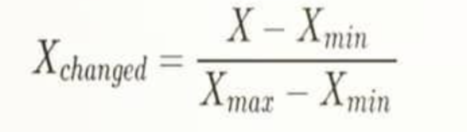

### Normalization Types:
- Min Max scaling
- Mean normalization
- Max absolute scaling
- Robust scaling

### Min Max Scaling
- bring values between 0 and 1

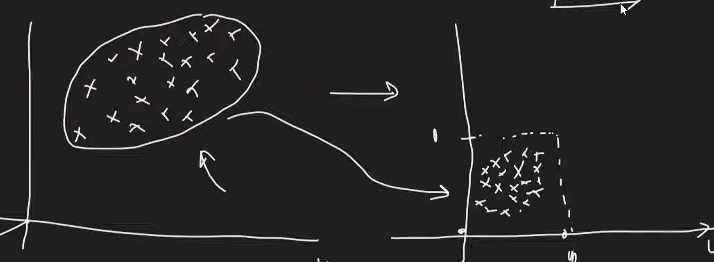

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [9]:
df = pd.read_csv('wine_data.csv', header=None, usecols=[0,1,2])
df.columns = ['Class label', 'Alcohol', 'Malic acid']

In [10]:
df.head()

,Class label,Alcohol,Malic acid
0,1,14.23,1.71
1,1,13.20,1.78
2,1,13.16,2.36
3,1,14.37,1.95
4,1,13.24,2.59


<Axes: xlabel='Alcohol', ylabel='Density'>

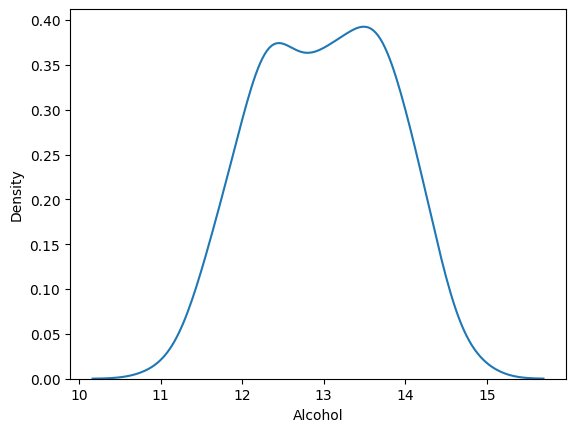

In [11]:
sns.kdeplot(df['Alcohol'])

<Axes: xlabel='Malic acid', ylabel='Density'>

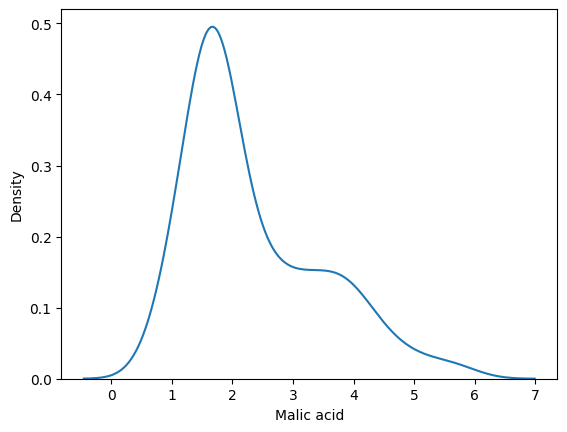

In [12]:
sns.kdeplot(df['Malic acid'])

<Axes: xlabel='Alcohol', ylabel='Malic acid'>

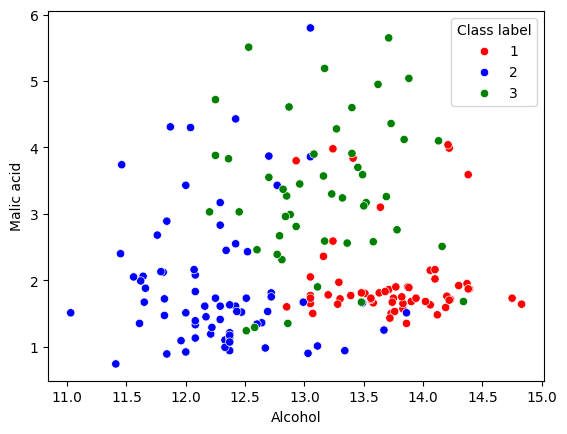

In [17]:
color_dict = {1:'red', 2:'blue', 3:'green'}
sns.scatterplot(x = df['Alcohol'] , y = df['Malic acid'], hue=df['Class label'], palette = color_dict)

In [20]:
from numpy.random import random_sample
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(df.drop('Class label', axis=1), df['Class label'], test_size=0.3, random_state=0)

X_train.shape, X_test.shape

((124, 2), (54, 2))

In [23]:
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()

# fit the scaler to the train set, it will learn the parameters
scaler.fit(X_train)

# transform, train and test sets
X_train_scaled, X_test_scaled = scaler.transform(X_train), scaler.transform(X_test)

In [24]:
X_train_scaled = pd.DataFrame(X_train_scaled, columns=X_train.columns)
X_test_scaled = pd.DataFrame(X_test_scaled, columns=X_test.columns)


In [27]:
X_train_scaled.head() , X_test_scaled.head()

(    Alcohol  Malic acid
 0  0.720430    0.203782
 1  0.319892    0.084034
 2  0.602151    0.712185
 3  0.572581    0.563025
 4  0.760753    0.130252,
     Alcohol  Malic acid
 0  0.728495    0.163866
 1  0.473118    0.373950
 2  0.360215    0.050420
 3  0.680108    0.176471
 4  0.543011    1.031513)

In [28]:
np.round(X_train_scaled.describe(), 1)

,Alcohol,Malic acid
count,124.0,124.0
mean,0.5,0.3
std,0.2,0.2
min,0.0,0.0
25%,0.4,0.2
50%,0.5,0.2
75%,0.7,0.5
max,1.0,1.0


In [30]:
np.round(X_test_scaled.describe(), 1)   # min and max will be guarenteed 0 and 1 respectively

,Alcohol,Malic acid
count,54.0,54.0
mean,0.5,0.3
std,0.2,0.2
min,0.1,-0.0
25%,0.4,0.1
50%,0.5,0.2
75%,0.7,0.4
max,1.0,1.0


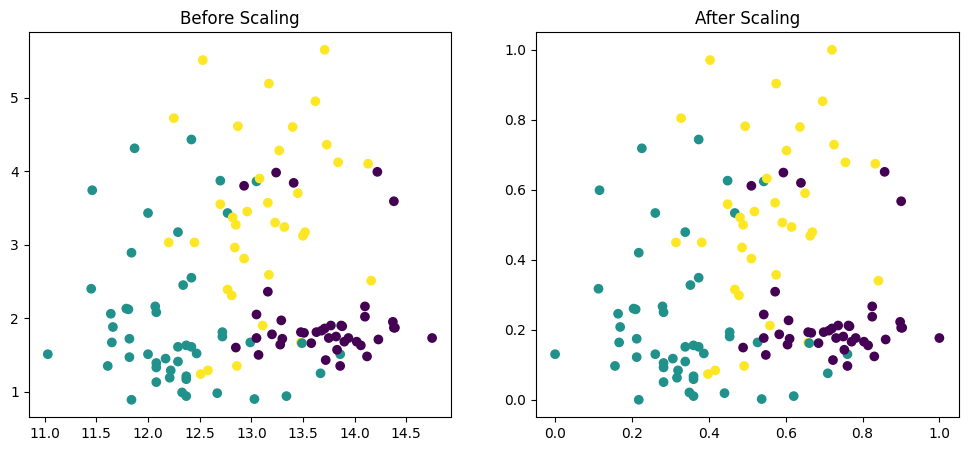

In [33]:
fig, (x1 , x2) = plt.subplots(ncols=2, figsize=(12,5))

x1.scatter(X_train['Alcohol'], X_train['Malic acid'], c=y_train)
x1.set_title("Before Scaling")

x2.scatter(X_train_scaled['Alcohol'], X_train_scaled['Malic acid'], c=y_train)
x2.set_title("After Scaling")

plt.show()


# left(before) and right(after scaling) are same in shape, except for the second which is squished in a unit square

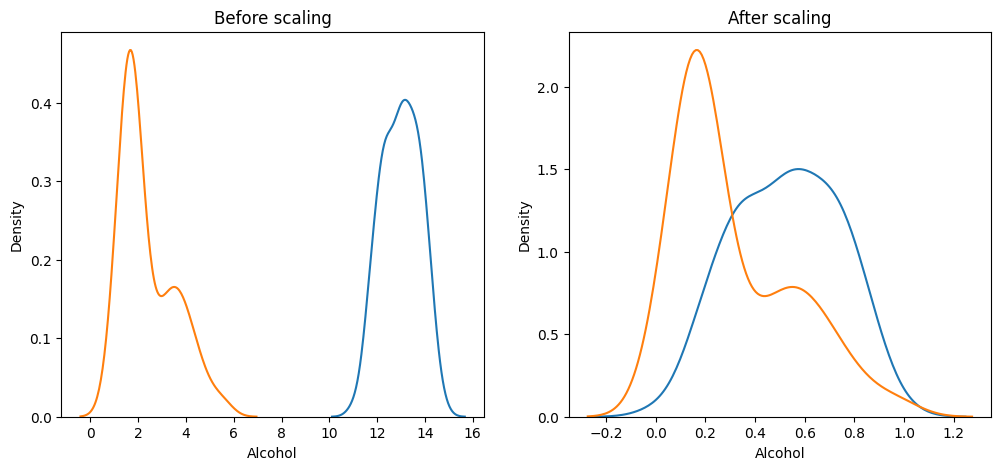

In [35]:
fig, (kx1, kx2) = plt.subplots(ncols = 2, figsize=(12,5))

# before scaling
sns.kdeplot(X_train['Alcohol'], ax=kx1)
sns.kdeplot(X_train['Malic acid'], ax=kx1)
kx1.set_title("Before scaling")

# after scaling
sns.kdeplot(X_train_scaled['Alcohol'], ax=kx2)
sns.kdeplot(X_train_scaled['Malic acid'], ax=kx2)
kx2.set_title("After scaling")

plt.show()

### Mean Normalization

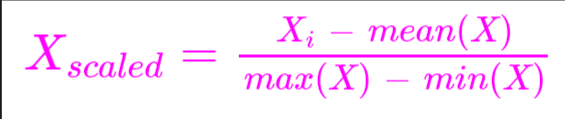

### Max absolute Scaling

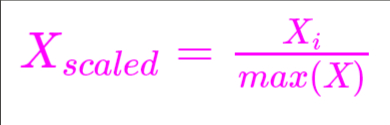

In [ ]:
# Max Absolute scaling is used when the data is sparse



---



### Robust Scaling

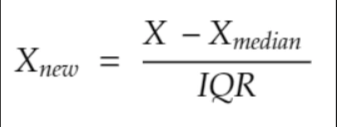

In [ ]:
# use robust scaling when your data has many outliers.



---



In [ ]:
# Normalization v/s Standardization

# is feature scaling required
# most of the problems reuire standardization
# min/max scaler is generally used when the minimum and maximum values are known


# min/max value known ---> Min Max Scaling
# Nothing is known ---> standard scaling
# outliers are present ---> robust scaling
# sparse matrix ---> Max Absolute scaling